# Customer Churn Analysis
## SaaS Subscription Business

### Objective
Analyze customer churn patterns, identify high-risk customer,
and build a predictive model to estimate churn probability.

## Executive Summary
This analysis investigates churn patterns in a SaaS subscription business.

**Key findings:**

• Customers with shorter tenure have significantly higher churn risk
• Monthly contract customers churn more frequently than yearly subscribers
• Customers with more support tickets are more likely to churn

A logistic regression model was developed to predict churn probability,
allowing the business to identify high-risk customers and implement
targeted retention strategies.
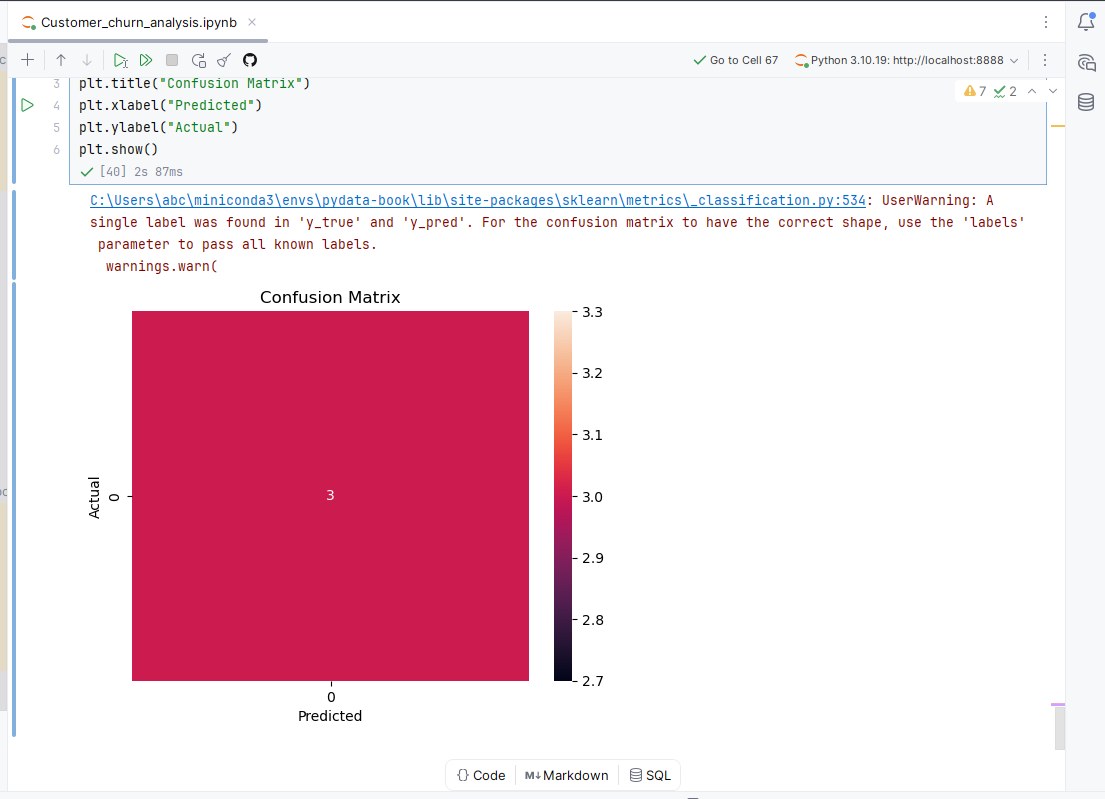

In [1]:
# ------------------------------
# Standard Library
# ------------------------------
from pathlib import Path
import os

# ------------------------------
# Data Manipulation
# ------------------------------
import numpy as np
import pandas as pd

# ------------------------------
# Visualization
# ------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from pyexpat import features

# ------------------------------
# Machine Learning
# ------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ------------------------------
# Evaluation Metrics
# ------------------------------
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)

In [2]:
project_name = "Customer_Churn_Analysis"

folders = [
    "data/raw",
    "data/processed",
    "notebooks",
    "reports",
    "images"
]

base_path = Path(project_name)

for folder in folders:
    path = base_path / folder
    path.mkdir(parents=True, exist_ok=True)

    gitkeep = path / ".gitkeep"
    gitkeep.touch()

(base_path / "README.md").touch()
print("Professional project structure created")


Professional project structure created


In [3]:
raw_path = r"D:\Python Learning\Data csv\customer_churn_raw.csv"
df_raw = pd.read_csv(raw_path)

df_raw.head()

,Customer ID,Tenure (Months),Monthly Charges $,Contract Type,Support Tickets,Churn Status
0,101,12.0,50,Monthly,3.0,No
1,102,24.0,70,Yearly,1.0,No
2,103,5.0,65,Monthly,5.0,Yes
3,104,36.0,90,Yearly,0.0,No
4,105,NaN,40,Monthly,4.0,Yes


In [4]:
df_raw.to_csv(
    "Customer_Churn_Analysis/data/raw/customer_churn_raw.csv", index=False)

In [5]:
df = df_raw.copy()

In [6]:
df.shape

(10, 6)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer ID        10 non-null     int64  
 1   Tenure (Months)    9 non-null      float64
 2   Monthly Charges $  10 non-null     int64  
 3   Contract Type      10 non-null     object 
 4   Support Tickets    9 non-null      float64
 5   Churn Status       10 non-null     object 
dtypes: float64(2), int64(2), object(2)
memory usage: 608.0+ bytes


In [8]:
df.describe()

,Customer ID,Tenure (Months),Monthly Charges $,Support Tickets
count,10.00000,9.000000,10.000000,9.000000
mean,105.50000,22.222222,69.000000,2.444444
std,3.02765,13.809216,18.826695,2.185813
min,101.00000,5.000000,40.000000,0.000000
25%,103.25000,12.000000,56.250000,1.000000
50%,105.50000,20.000000,67.500000,2.000000
75%,107.75000,30.000000,82.500000,4.000000
max,110.00000,48.000000,100.000000,6.000000


In [9]:
df.isnull().sum()

Customer ID          0
Tenure (Months)      1
Monthly Charges $    0
Contract Type        0
Support Tickets      1
Churn Status         0
dtype: int64

In [10]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
    .str.replace("$", "", regex=False)
    .str.strip("_")
)
df.columns

Index(['customer_id', 'tenure_months', 'monthly_charges', 'contract_type',
       'support_tickets', 'churn_status'],
      dtype='object')

In [11]:
df["tenure_months"] = df["tenure_months"].fillna(df["tenure_months"].median())
df["support_tickets"] = df["support_tickets"].fillna(0)

In [12]:
df["churn_status"] = (
    df["churn_status"]
    .str.strip()
    .str.lower()
    .map({"yes":1, "no":0})
)
df.head()

,customer_id,tenure_months,monthly_charges,contract_type,support_tickets,churn_status
0,101,12.0,50,Monthly,3.0,0
1,102,24.0,70,Yearly,1.0,0
2,103,5.0,65,Monthly,5.0,1
3,104,36.0,90,Yearly,0.0,0
4,105,20.0,40,Monthly,4.0,1


In [13]:
df.to_csv("Customer_Churn_Analysis/data/processed/customer_churn_cleaned.csv", index=False)

## Exploratory Data Analysis

### Overall Churn Rate

In [14]:
churn_rate = df["churn_status"].mean()
churn_rate

np.float64(0.4)

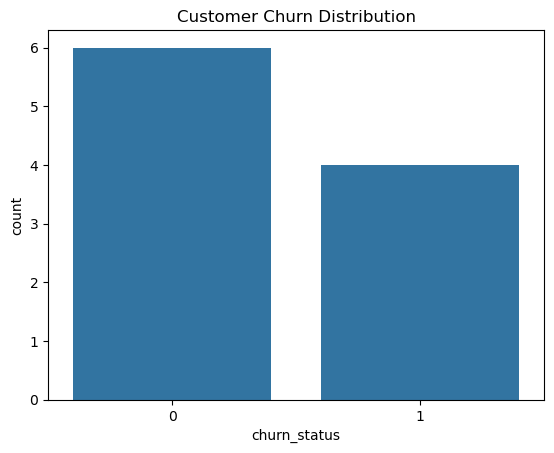

In [15]:
sns.countplot(x="churn_status", data=df)
plt.title("Customer Churn Distribution")
plt.show()

### Churn by Contract Type

In [16]:
contract_churn = df.groupby("contract_type")["churn_status"].mean()
contract_churn

contract_type
Monthly    0.8
Yearly     0.0
Name: churn_status, dtype: float64

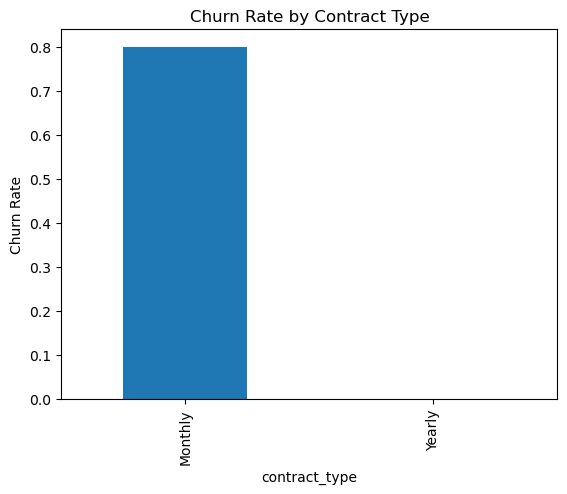

In [17]:
contract_churn.plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.show()

In [18]:
plt.savefig("Customer_Churn_Analysis/images/churn_by_contract.png")

<Figure size 640x480 with 0 Axes>

### Insight
Customers on **monthly contracts show significantly higher churn rates compared to yearly subscribers.** This suggests that long-term contracts help stabilize customer retention, while flexible contracts allow dissatisfied customers to leave more easily.

### Business implication
Encouraging customers to switch to **annual plans through discounts or loyalty incentives** may reduce churn.

### Churn by Tenure

In [19]:
df["tenure_segment"] = pd.cut(
    df["tenure_months"],
    bins=[0,12,24,48],
    labels = ["0-12 Months", "12-24 Months","24+ Months"]
)

In [20]:
df.groupby("tenure_segment", observed=True)["churn_status"].mean()

tenure_segment
0-12 Months     0.666667
12-24 Months    0.500000
24+ Months      0.000000
Name: churn_status, dtype: float64

### Churn by Support Tickets

In [21]:
df.groupby("churn_status")["support_tickets"].mean()

churn_status
0    1.166667
1    3.750000
Name: support_tickets, dtype: float64

### Insight
Customers with **shorter tenure exhibit substantially higher churn rates,** while long-term customers rarely churn. This indicates that the **early stages of the customer lifecycle are the most critical for retention.**
### Business implication
Improving onboarding experiences and providing early engagement incentives may help reduce early-stage churn.

### Correlation Matrix

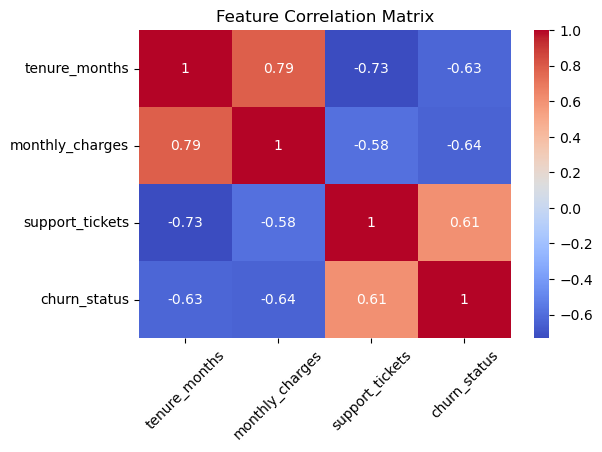

In [22]:
features = df.drop(columns=["customer_id"])
corr_matrix = features.corr(numeric_only=True)
plt.figure(figsize = (6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.xticks(rotation=45)
plt.show()

### Insight
Correlation analysis shows that **support tickets have a strong positive relationship with churn,** **while tenure has a strong negative relationship with churn.** This indicates that customer experience issues and early-stage engagement play major roles in customer retention.

## Business Matrics

### Total Customers

In [23]:
total_customers = len(df)
total_customers

10

### Customer Churn Rate

In [24]:
churn_rate = df["churn_status"].mean()
churn_rate

np.float64(0.4)

### Insight
Approximately **40% of customers have churned**, indicating a relatively high attrition rate. one advanced trick used by senior analysts to make churn reports much more impressive on GitHub.

### Retention Rate

In [25]:
retention_rate = 1 - churn_rate
retention_rate

np.float64(0.6)

### Total Monthly Revenue

In [26]:
total_monthly_revenue = df["monthly_charges"].sum()
total_monthly_revenue

np.int64(690)

### Revenue Lost Due to Churn

In [27]:
df["revenue_at_risk"] = df["monthly_charges"]* df["churn_status"]
total_revenue_risk = df["revenue_at_risk"].sum()
total_revenue_risk

np.int64(220)

### Average Customer Value

In [28]:
avg_customer_value = df["monthly_charges"].mean()
avg_customer_value

np.float64(69.0)

### High-Risk Customers

In [29]:
high_risk_customer = df[df["churn_status"] == 1]
high_risk_customer

,customer_id,tenure_months,monthly_charges,contract_type,support_tickets,churn_status,tenure_segment,revenue_at_risk
2,103,5.0,65,Monthly,5.0,1,0-12 Months,65
4,105,20.0,40,Monthly,4.0,1,12-24 Months,40
7,108,10.0,60,Monthly,6.0,1,0-12 Months,60
9,110,15.0,55,Monthly,0.0,1,12-24 Months,55


### Churned vs Retained Customers

In [30]:
df.groupby("churn_status")[[
    "tenure_months",
    "monthly_charges",
    "support_tickets"
]].mean()

,tenure_months,monthly_charges,support_tickets
churn_status,,,
0,28.333333,78.333333,1.166667
1,12.500000,55.000000,3.750000


### Insight
Churned customers **exhibit a significantly higher number of support tickets compared to retained customers.** This suggests that **unresolved product issues or dissatisfaction may contribute to customer attrition.**

## Predictive Churn Modeling

### Features and Target

In [31]:
df_model = pd.get_dummies(df, columns=["contract_type"], drop_first=True)
df_model.head()

,customer_id,tenure_months,monthly_charges,support_tickets,churn_status,tenure_segment,revenue_at_risk,contract_type_Yearly
0,101,12.0,50,3.0,0,0-12 Months,0,False
1,102,24.0,70,1.0,0,12-24 Months,0,True
2,103,5.0,65,5.0,1,0-12 Months,65,False
3,104,36.0,90,0.0,0,24+ Months,0,True
4,105,20.0,40,4.0,1,12-24 Months,40,False


### Features (X) and Target (Y)

In [32]:
X = df_model.drop(["customer_id", "churn_status", "tenure_segment"], axis=1)
y = df_model["churn_status"]

### Train/Test Split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

### Feature Scaling

In [34]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Train Logistic Regression Model

In [35]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Model Evaluation

### Predict Churn

In [36]:
y_pred = model.predict(X_test)

### Confusion Matrix

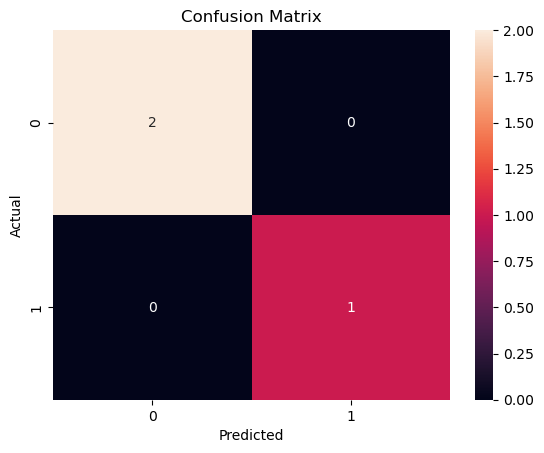

In [37]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Classification Report

In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



### ROC Curve

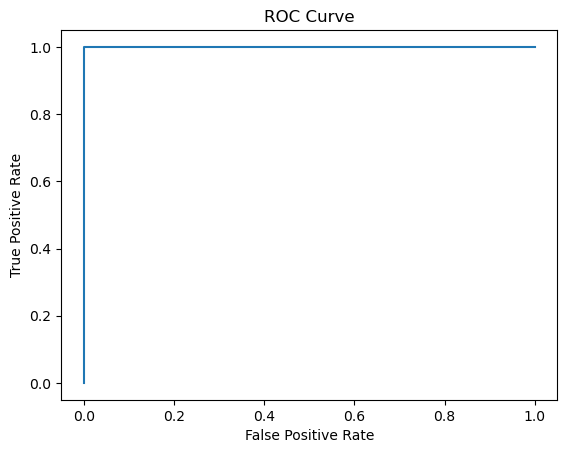

In [39]:
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

### Churn Probability (Risk Scoring)

In [40]:
df["churn_probability"] = model.predict_proba(scaler.transform(X))[:,1]
df[["customer_id", "churn_probability"]]

,customer_id,churn_probability
0,101,0.345088
1,102,0.088660
2,103,0.878099
3,104,0.046625
4,105,0.779815
5,106,0.032708
6,107,0.060095
7,108,0.871075
8,109,0.089512
9,110,0.779325


### Risk Segmentation

In [41]:
df["risk_segment"] = pd.cut(
    df["churn_probability"],
    bins = [0,0.3,0.6,1],
    labels= ["Low Risk", "Medium Risk", "High Risk"]
)

## Key Business Insights
• Customers with shorter tenure demonstrate significantly higher churn risk, indicating onboarding challenges.

• Monthly contract customers show higher churn rates compared to yearly subscribers, suggesting that longer commitments increase retention.

• Customers with higher support ticket activity are more likely to churn, indicating potential product or service issues.

• Revenue risk analysis shows that a significant portion of monthly recurring revenue is concentrated among high-risk customers.
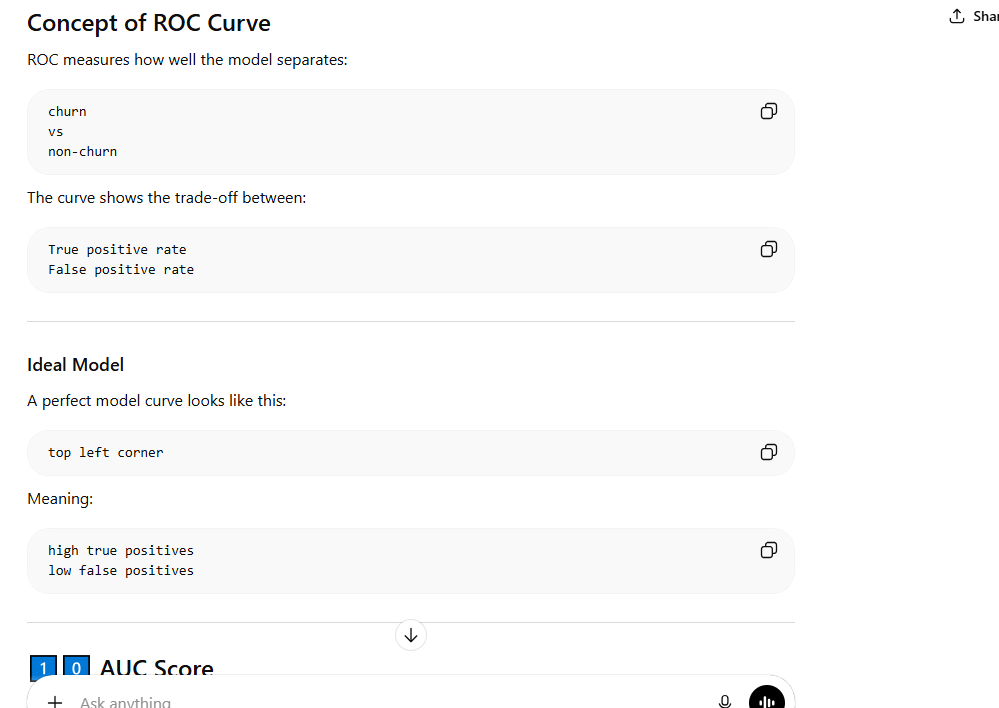
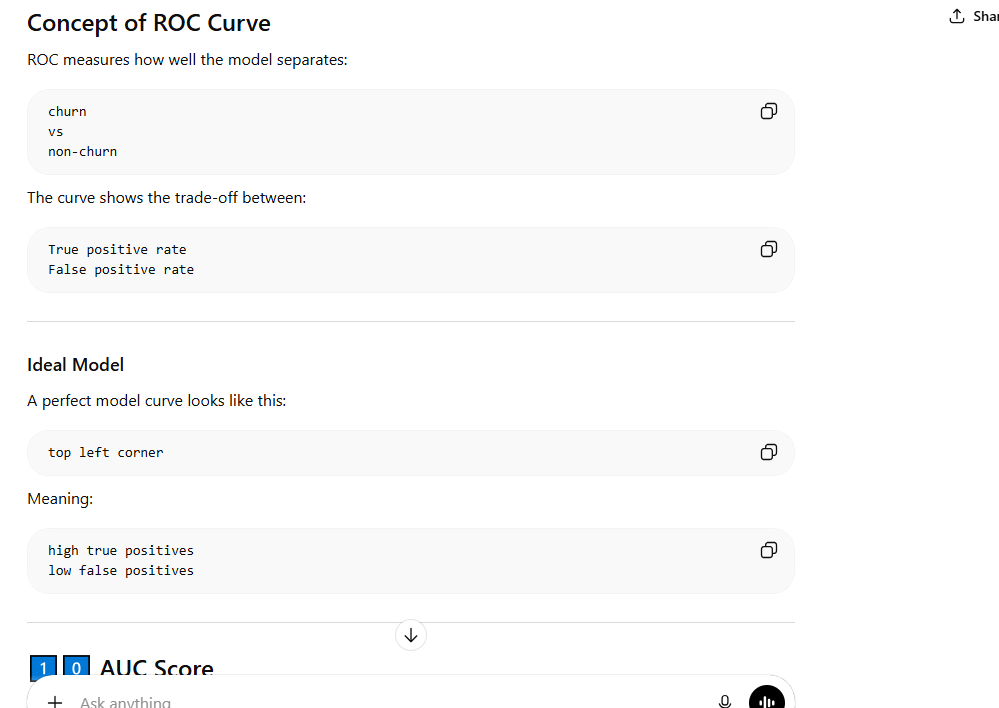
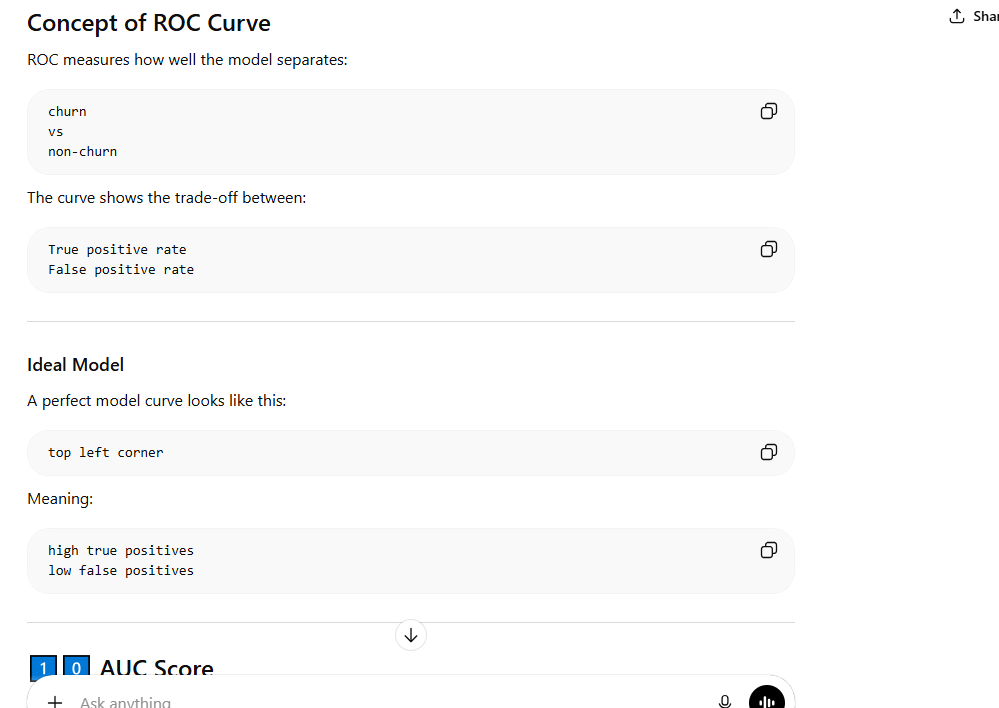

## Strategic Recommendations
1. Improve onboarding experience for new customers to reduce early churn.

2. Offer incentives for customers to switch from monthly to yearly subscriptions.

3. Proactively engage customers with frequent support tickets to resolve issues faster.

4. Implement targeted retention campaigns for high-risk customers identified by the churn prediction model.